In [17]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
import pickle

In [18]:
#basic analysis
data_path = Path("../data/processed/NVDA_outliers.csv")
df = pd.read_csv(data_path)
df["mom_5"] = (df["adj close"]/df["adj close"].shift(5)-1).shift(1)
df["log_return"] = np.log(df["adj close"]).diff().shift(1)
df["vol_std_5"] = df["log_return"].rolling(5).std().shift(1)
df['next_excess_return'] = df['excess_return'].shift(-1) 
df = df.copy().dropna().reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

In [19]:
cut=int(len(df)*0.8)
train, test = df.iloc[:cut], df.iloc[cut:]
features=['vol_std_5','mom_5',"log_return"] 
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['next_excess_return'], test['next_excess_return']
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)

In [20]:
with open('../model/model.pkl', 'wb') as f:
    pickle.dump(reg, f)

# TODO: Test loading the model
with open('../model/model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Example prediction (replace with actual features)
payload  = {'vol_std_5': 0.1,'mom_5': 0.2, 'log_return': 0.3}
x = pd.DataFrame([payload], columns=features) 
print(loaded_model.predict(x))

[-0.00894612]


In [21]:
from flask import Flask, request, jsonify
import threading
import matplotlib.pyplot as plt
import io
import base64

app = Flask(__name__)


@app.route('/predict', methods=['POST'])
def predict_post():
    vals = request.get_json()['features']          
    X = pd.DataFrame([vals], columns=features)     
    y = float(reg.predict(X)[0])
    return jsonify({'prediction': y})

@app.route('/predict/<float:input1>', methods=['GET'])
def predict_one(input1):
    X = pd.DataFrame([[input1, 0.0, 0.0]], columns=features)
    y = float(reg.predict(X)[0])
    return jsonify({'prediction': y})

@app.route('/predict/<float:input1>/<float:input2>', methods=['GET'])
def predict_two(input1, input2):
    X = pd.DataFrame([[input1, input2, 0.0]], columns=features)
    y = float(reg.predict(X)[0])
    return jsonify({'prediction': y})

@app.route('/plot', methods=['GET'])
def plot():
    import io, base64
    import numpy as np
    import matplotlib.pyplot as plt

    n = int(request.args.get('n', 252))
    cols = features + ['next_excess_return', 'date']
    data = df[cols].dropna().tail(n).copy()

    Xn = data[features]
    data['y_pred'] = reg.predict(Xn)

    rmse = np.sqrt(np.mean((data['next_excess_return'] - data['y_pred'])**2))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(data['date'], data['next_excess_return'], label='Truth', linewidth=1)
    ax.plot(data['date'], data['y_pred'], label='Prediction', linewidth=1)
    ax.set_title(f'Prediction vs Truth (last {len(data)} days) — RMSE: {rmse:.5f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('next_excess_return')
    ax.legend()
    fig.autofmt_xdate()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')
    return f'<img src="data:image/png;base64,{img_b64}"/>'

# @app.route('/predict', methods=['POST'])
# def predict():
#     # TODO: Replace placeholder logic with actual model prediction
#     data = request.get_json()
#     features = data.get('features', None)
#     if features is None:
#         return jsonify({'error': 'No features provided'}), 400
#     pred = sum(features)  # placeholder
#     return jsonify({'prediction': pred})

# @app.route('/predict/<float:input1>', methods=['GET'])
# def predict_one(input1):
#     pred = input1 * 2  # placeholder
#     return jsonify({'prediction': pred})

# @app.route('/predict/<float:input1>/<float:input2>', methods=['GET'])
# def predict_two(input1, input2):
#     pred = input1 + input2  # placeholder
#     return jsonify({'prediction': pred})

# @app.route('/plot')
# def plot():
#     # TODO: Replace with meaningful chart or image
#     fig, ax = plt.subplots()
#     ax.plot([0, 1, 2], [0, 1, 4])
#     buf = io.BytesIO()
#     fig.savefig(buf, format='png')
#     buf.seek(0)
#     img_bytes = base64.b64encode(buf.read()).decode('utf-8')
#     return f'<img src="data:image/png;base64,{img_bytes}"/>'
def run_flask():
    app.run(port=5000)

# Launch Flask in a separate thread
threading.Thread(target=run_flask).start()

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.
On macOS, try disabling the 'AirPlay Receiver' service from System Preferences -> General -> AirDrop & Handoff.


{'prediction': -0.008946118626429998}
{'prediction': -0.0477769151288692}
{'prediction': 0.0092214179825105}



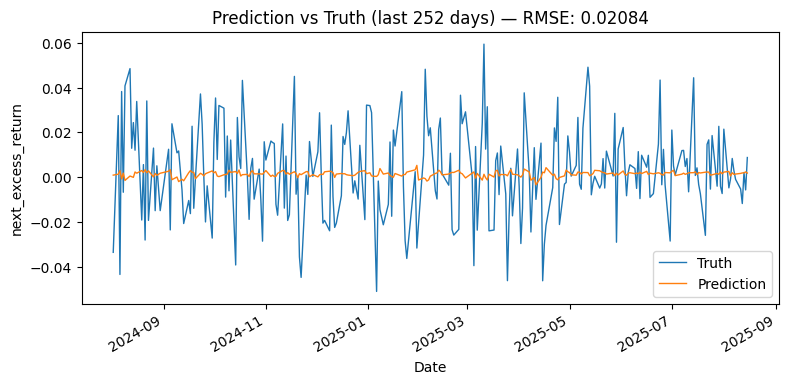

In [22]:
import requests
from IPython.display import display, HTML

# POST /predict
payload = {
    'features': {
        'mom_5': 0.2,
        'log_return': 0.3,
        'vol_std_5': 0.1
    }
}
response = requests.post(
    'http://127.0.0.1:5000/predict',
    json=payload
)
print(response.json())

# GET /predict/<input1>
response2 = requests.get('http://127.0.0.1:5000/predict/2.0')
print(response2.json())

# GET /predict/<input1>/<input2>
response3 = requests.get('http://127.0.0.1:5000/predict/1.0/3.0')
print(response3.json())

# GET /plot
response_plot = requests.get('http://127.0.0.1:5000/plot')
display(HTML(response_plot.text))